# Projet Méthodes Stochastiques — notebook

Code et simulations du projet proie-prédateur avec virus. Le contexte, la démarche
et la discussion des résultats sont dans le rapport ; ce notebook se concentre sur
le code qui charge les données, estime les paramètres et régénère les figures.

## Question 1 — modèle du virus (`virus4.csv`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Le fichier n'a pas d'en-tete : on nomme les colonnes a la main.
data = pd.read_csv("virus4.csv", header=None, names=["V", "P"])
V = data["V"].values
P = data["P"].values
N = len(data)
N

2000

### Estimation du pas de temps `dt`

In [2]:
# L'equation des predateurs est deterministe (dP = P(-1+V)dt) : on inverse le
# schema d'Euler pour estimer dt point par point, puis on moyenne. On ecarte les
# points ou V est proche de 1, qui annulent le denominateur.
dP = np.diff(P)
denom = P[:-1] * (-1 + V[:-1])
masque = np.abs(V[:-1] - 1) > 0.05

dt = np.mean(dP[masque] / denom[masque])
tau = N * dt
print(f"dt ~ {dt:.4f}, tau ~ {tau:.1f}")

dt ~ 0.0150, tau ~ 30.0


### Populations observées

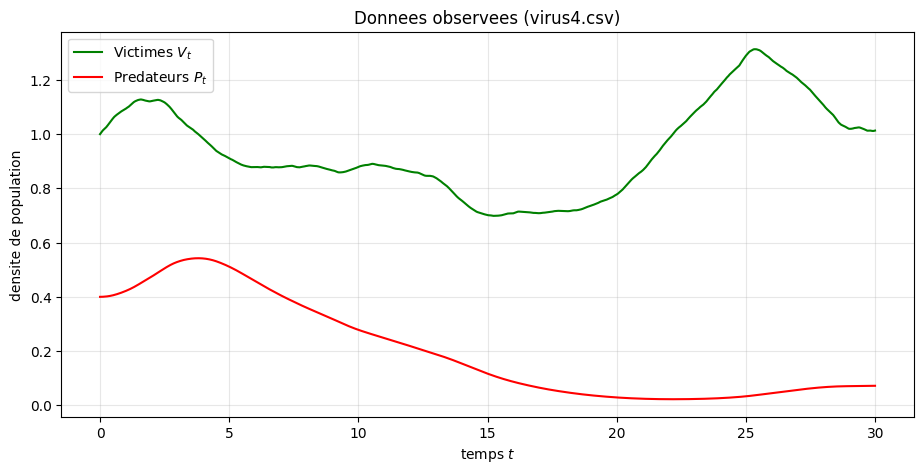

In [3]:
t = np.arange(N) * dt

plt.figure(figsize=(11, 5))
plt.plot(t, V, color="green", label="Victimes $V_t$")
plt.plot(t, P, color="red", label="Predateurs $P_t$")
plt.xlabel("temps $t$")
plt.ylabel("densite de population")
plt.title("Donnees observees (virus4.csv)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparaison avec le modèle de Lotka-Volterra classique (sans $X_t$)

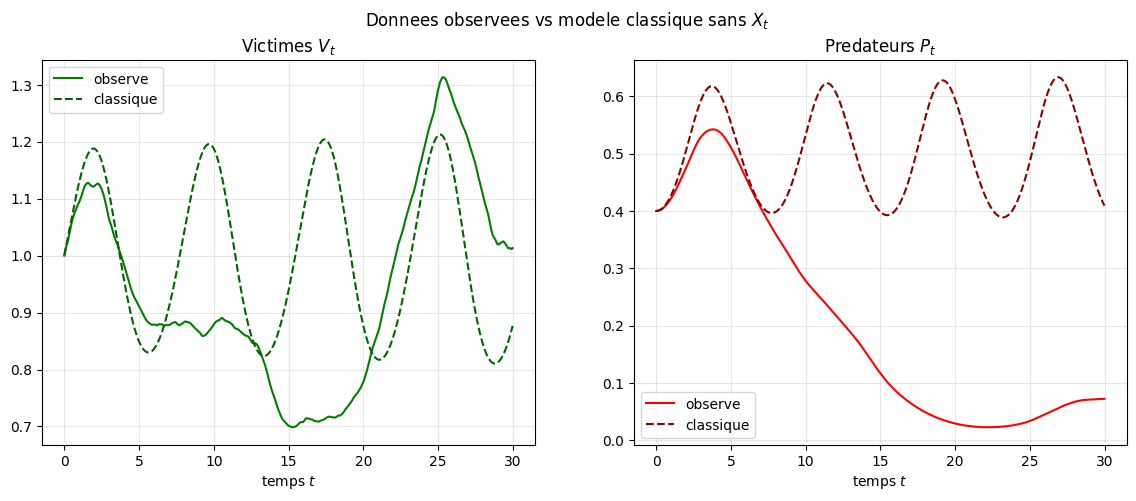

In [4]:
a, b, c, d = 2/3, 4/3, 1, 1

Vc = np.zeros(N)
Pc = np.zeros(N)
Vc[0], Pc[0] = V[0], P[0]   # memes conditions initiales que les donnees

# Euler explicite sur la meme grille de temps que les observations.
for i in range(N - 1):
    Vc[i+1] = Vc[i] + Vc[i] * (a - b * Pc[i]) * dt
    Pc[i+1] = Pc[i] + Pc[i] * (-c + d * Vc[i]) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Donnees observees vs modele classique sans $X_t$")

axes[0].plot(t, V, color="green", label="observe")
axes[0].plot(t, Vc, color="darkgreen", linestyle="--", label="classique")
axes[0].set_title("Victimes $V_t$")
axes[0].set_xlabel("temps $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, P, color="red", label="observe")
axes[1].plot(t, Pc, color="darkred", linestyle="--", label="classique")
axes[1].set_title("Predateurs $P_t$")
axes[1].set_xlabel("temps $t$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### Reconstruction du virus $X_t$

In [5]:
# Discretisation directe de l'equation des proies :
#   V[i] - V[i-1] = V[i-1] (2/3 - 4/3 P[i-1] + X[i-1]) dt
# d'ou X[i-1] = (V[i]-V[i-1]) / (V[i-1] dt) - 2/3 + 4/3 P[i-1].
dV = np.diff(V)
X = dV / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
tX = t[:-1]   # X[k] est attache au temps t[k]

# Artefact deterministe, sauvegarde pour que tout le monde reparte de la meme serie.
pd.DataFrame({"t": tX, "X": X}).to_csv("virus4_Xt.csv", index=False)
print(f"X reconstruit : {len(X)} points")

X reconstruit : 1999 points


### $X_t$ et ses différences $\Delta X_t$

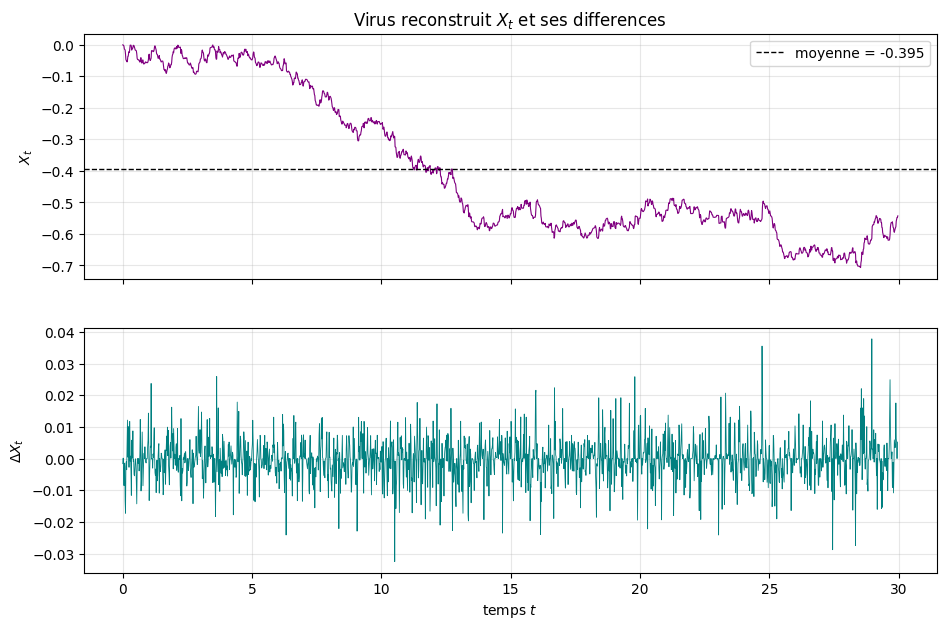

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(tX, X, color="purple", lw=0.8)
axes[0].axhline(X.mean(), color="black", ls="--", lw=1, label=f"moyenne = {X.mean():.3f}")
axes[0].set_ylabel("$X_t$")
axes[0].set_title("Virus reconstruit $X_t$ et ses differences")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(tX[:-1], np.diff(X), color="teal", lw=0.6)
axes[1].set_xlabel("temps $t$")
axes[1].set_ylabel(r"$\Delta X_t$")
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_Xt.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistiques de $X_t$ et $\Delta X_t$

Pour les différences, l'écart-type brut dépend du pas `dt` ; l'échelle qui a un sens est le
coefficient de diffusion $\sigma = \text{std}(\Delta X)/\sqrt{dt}$. On regarde aussi
l'asymétrie et la kurtosis pour juger de la normalité des différences.

In [7]:
dX = np.diff(X)
sigma = dX.std() / np.sqrt(dt)   # coefficient de diffusion, independant de dt

stats = pd.DataFrame(
    {"moyenne": [X.mean(), dX.mean()], "ecart-type": [X.std(), dX.std()]},
    index=["X_t", "dX_t"],
)
print(stats)
print(f"\nsigma = std(dX)/sqrt(dt) = {sigma:.4f}")
print(f"differences dX : asymetrie = {scs.skew(dX):.2f}, kurtosis exces = {scs.kurtosis(dX):.2f}")

       moyenne  ecart-type
X_t  -0.395169    0.227932
dX_t -0.000272    0.006381

sigma = std(dX)/sqrt(dt) = 0.0521
differences dX : asymetrie = 0.03, kurtosis exces = 3.33


### Gaussianité des différences $\Delta X_t$

On compare l'histogramme des différences à une loi normale de mêmes moyenne et écart-type.

test KS (normalite des differences) : D = 0.0881, p-value = 6.12e-14


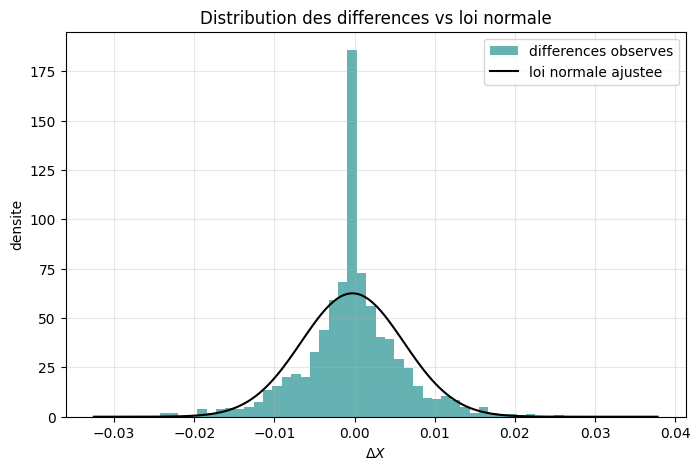

In [8]:
loi = scs.norm(dX.mean(), dX.std())   # normale calee sur moyenne et ecart-type des differences
ks = scs.kstest(dX, loi.cdf)
print(f"test KS (normalite des differences) : D = {ks.statistic:.4f}, p-value = {ks.pvalue:.2e}")
xx = np.linspace(dX.min(), dX.max(), 300)

plt.figure(figsize=(8, 5))
plt.hist(dX, bins=60, density=True, color="teal", alpha=0.6, label="differences observes")
plt.plot(xx, loi.pdf(xx), color="black", lw=1.5, label="loi normale ajustee")
plt.xlabel(r"$\Delta X$")
plt.ylabel("densite")
plt.title("Distribution des differences vs loi normale")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_dXt_hist.png", dpi=150, bbox_inches="tight")
plt.show()

### Estimation des candidats : OU et brownien avec dérive

In [9]:
# Deux candidats que rien ne permet d'ecarter a priori.
# OU : dX = theta(mu - X)dt + sigma dB  ->  regression de dX sur X.
pente, ord0 = np.polyfit(X[:-1], dX, 1)
theta = -pente / dt
mu = ord0 / (-pente)
sigma = (dX - (pente * X[:-1] + ord0)).std() / np.sqrt(dt)
# Brownien avec derive : dX = nu dt + sigma dB.
nu = dX.mean() / dt
sigma_d = dX.std() / np.sqrt(dt)
print(f'OU     : theta = {theta:.3f}, mu = {mu:.3f}, sigma = {sigma:.3f}')
print(f'derive : nu = {nu:.4f}, sigma = {sigma_d:.3f}')

OU     : theta = 0.069, mu = -0.657, sigma = 0.052
derive : nu = -0.0181, sigma = 0.052


### Validation : simulation de $(V,P)$ et test de Kolmogorov-Smirnov

On simule $X_t$ selon chaque modele, on l'injecte dans le systeme pour obtenir $(V,P)$, puis on compare aux donnees par un test KS a deux echantillons.

In [10]:
def integ_VP(Xp):
    # Systeme couple, conditions initiales observees.
    Vs = np.empty(N); Ps = np.empty(N); Vs[0] = V[0]; Ps[0] = P[0]
    for i in range(N - 1):
        Vs[i+1] = Vs[i] + Vs[i] * (2/3 - 4/3 * Ps[i] + Xp[i]) * dt
        Ps[i+1] = Ps[i] + Ps[i] * (-1 + Vs[i]) * dt
    return Vs, Ps

def simule_X(kind):
    Y = np.zeros(N); e = scs.norm(0, 1).rvs(size=N - 1)
    for i in range(N - 1):
        drift = theta * (mu - Y[i]) if kind == 'ou' else nu
        s = sigma if kind == 'ou' else sigma_d
        Y[i+1] = Y[i] + drift * dt + s * np.sqrt(dt) * e[i]
    return Y

M = 200
for kind in ('ou', 'derive'):
    DV = []; DP = []; pV = []; pP = []
    for _ in range(M):
        Vs, Ps = integ_VP(simule_X(kind))
        rV = scs.ks_2samp(V, Vs); rP = scs.ks_2samp(P, Ps)
        DV.append(rV.statistic); DP.append(rP.statistic); pV.append(rV.pvalue); pP.append(rP.pvalue)
    print(f'{kind:7s}: D_V={np.median(DV):.3f}, D_P={np.median(DP):.3f}, p_V~{np.median(pV):.1e}, p_P~{np.median(pP):.1e}')

ou     : D_V=0.244, D_P=0.332, p_V~2.8e-52, p_P~1.2e-97


derive : D_V=0.236, D_P=0.388, p_V~1.9e-49, p_P~1.6e-133


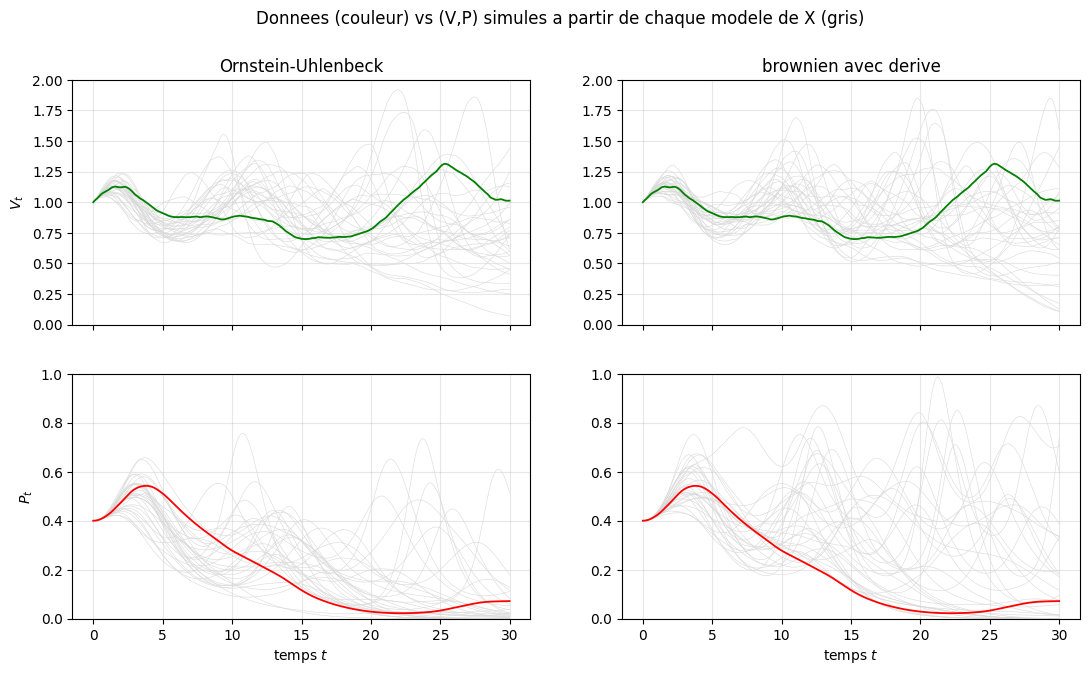

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for j, kind in enumerate(('ou', 'derive')):
    for _ in range(30):
        Vs, Ps = integ_VP(simule_X(kind))
        ax[0, j].plot(t, Vs, color='0.85', lw=0.4)
        ax[1, j].plot(t, Ps, color='0.85', lw=0.4)
    ax[0, j].plot(t, V, color='green', lw=1.3)
    ax[1, j].plot(t, P, color='red', lw=1.3)
    ax[0, j].set_title('Ornstein-Uhlenbeck' if kind == 'ou' else 'brownien avec derive')
    ax[0, j].set_ylim(0, 2); ax[1, j].set_ylim(0, 1); ax[0, j].grid(alpha=0.3); ax[1, j].grid(alpha=0.3)
ax[0, 0].set_ylabel('$V_t$'); ax[1, 0].set_ylabel('$P_t$')
ax[1, 0].set_xlabel('temps $t$'); ax[1, 1].set_xlabel('temps $t$')
fig.suptitle('Donnees (couleur) vs (V,P) simules a partir de chaque modele de X (gris)')
plt.savefig('figures/virus4_vp_validation.png', dpi=150, bbox_inches='tight')
plt.show()